In [4]:
import warnings
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from category_encoders import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In [5]:
def wrangle(filepath):
    df = pd.read_csv(filepath)

    # Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]

    # Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]

    # Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    # add new column called neighborhood
    df["neighborhood"] = df["place_with_parent_names"].str.split("|", expand=True)[3]
    df.drop(columns="place_with_parent_names", inplace=True)

    return df

In [6]:
files = glob('data/buenos-aires-real-estate-*.csv')
files

['data\\buenos-aires-real-estate-1.csv',
 'data\\buenos-aires-real-estate-2.csv',
 'data\\buenos-aires-real-estate-3.csv',
 'data\\buenos-aires-real-estate-4.csv',
 'data\\buenos-aires-real-estate-5.csv']

In [7]:
frame = []
for file in files:
    df = wrangle(file)
    frame.append(df)

df = pd.concat(frame, ignore_index=True)
df.head()

,operation,property_type,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon,neighborhood
0,sell,apartment,129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,-34.584651,-58.454693,Chacarita
1,sell,apartment,87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,-34.638979,-58.500115,Villa Luro
2,sell,apartment,118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,-34.615847,-58.459957,Caballito
3,sell,apartment,57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...,-34.625222,-58.382382,Constitución
4,sell,apartment,90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...,-34.610610,-58.412511,Once


In [8]:
feature = ["neighborhood"]
target = "price_aprox_usd"

X_train = df[feature]
y_train = df[target]

In [9]:
y_mean = y_train.mean()
y_pre_baseline = [y_mean] * len(y_train)

print(f'mean absolute error {round(mean_absolute_error(y_train, y_pre_baseline), 2)}')

mean absolute error 44860.11


In [10]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    LinearRegression()
)

model.fit(X_train, y_train)

c:\Users\user\Documents\world-quantum\venv\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehotencoder', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,['neighborhood']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


In [11]:
pre_values = model.predict(X_train)

print(f'mean absolute error {round(mean_absolute_error(y_train, pre_values), 2)}')

mean absolute error 39339.72


In [12]:
X_test = pd.read_csv("data/buenos-aires-test-features.csv")[feature]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

0    249409.478261
1    161530.079797
2     98036.930192
3    110675.394444
4    127796.268745
dtype: float64

In [13]:
intercept = model.named_steps["linearregression"].intercept_
coefficients = model.named_steps["linearregression"].coef_
print("coefficients len:", len(coefficients))
print(coefficients[:5])

coefficients len: 57
[ -1910.75043614   1046.27470672  10324.25164214 -41623.85243614
  -2217.13905402]


In [14]:
feature_names = model.named_steps["onehotencoder"].get_feature_names()
print("features len:", len(feature_names))
print(feature_names[:5])

features len: 57
['neighborhood_Chacarita' 'neighborhood_Villa Luro'
 'neighborhood_Caballito' 'neighborhood_Constitución' 'neighborhood_Once']


In [15]:
coefficients = model.named_steps["linearregression"].coef_
features = model.named_steps["onehotencoder"].get_feature_names_out()
feat_imp = pd.Series(coefficients, index=features)
feat_imp = feat_imp.reindex(feat_imp.abs().sort_values().index)

feat_imp

neighborhood_Agronomía                  246.330723
neighborhood_Villa Luro                1046.274707
neighborhood_Chacarita                -1910.750436
neighborhood_Once                     -2217.139054
neighborhood_Monte Castro             -2506.632487
neighborhood_Barracas                 -3599.986147
neighborhood_Almagro                   3964.479965
neighborhood_Versalles                -4872.017103
neighborhood_Villa Devoto              4957.080624
neighborhood_Parque Centenario        -5425.285395
neighborhood_Abasto                    5571.461158
neighborhood_Boedo                    -5846.931739
neighborhood_Paternal                 -6178.158310
neighborhood_San Telmo                 6723.691857
neighborhood_Parque Chacabuco         -6796.622658
neighborhood_Centro / Microcentro     -6993.830674
neighborhood_Congreso                 -7000.990271
neighborhood_Villa Pueyrredón         -7193.526537
neighborhood_Tribunales               -7199.794881
neighborhood_Villa Crespo      

In [16]:
feat_imp = pd.Series(coefficients, index=feature_names)
feat_imp.head()

neighborhood_Chacarita       -1910.750436
neighborhood_Villa Luro       1046.274707
neighborhood_Caballito       10324.251642
neighborhood_Constitución   -41623.852436
neighborhood_Once            -2217.139054
dtype: float64

In [17]:
print(f"price = {intercept.round(2)}")
for f, c in feat_imp.items():
    print(f"+ ({round(c, 2)} * {f})")

price = 117472.02
+ (-1910.75 * neighborhood_Chacarita)
+ (1046.27 * neighborhood_Villa Luro)
+ (10324.25 * neighborhood_Caballito)
+ (-41623.85 * neighborhood_Constitución)
+ (-2217.14 * neighborhood_Once)
+ (3964.48 * neighborhood_Almagro)
+ (47056.22 * neighborhood_Palermo)
+ (-7638.72 * neighborhood_Flores)
+ (48091.9 * neighborhood_Belgrano)
+ (-12974.93 * neighborhood_Liniers)
+ (7345.22 * neighborhood_Villa Crespo)
+ (-9700.16 * neighborhood_San Cristobal)
+ (-7000.99 * neighborhood_Congreso)
+ (15837.8 * neighborhood_Saavedra)
+ (-10169.8 * neighborhood_Balvanera)
+ (-30505.35 * neighborhood_Parque Avellaneda)
+ (74291.64 * neighborhood_Recoleta)
+ (6723.69 * neighborhood_San Telmo)
+ (44058.06 * neighborhood_Nuñez)
+ (56930.11 * neighborhood_Barrio Norte)
+ (-5425.29 * neighborhood_Parque Centenario)
+ (5571.46 * neighborhood_Abasto)
+ (-6993.83 * neighborhood_Centro / Microcentro)
+ (-18554.34 * neighborhood_)
+ (-6178.16 * neighborhood_Paternal)
+ (-20474.63 * neighborhood_M

Text(0.5, 1.0, 'feature importance')

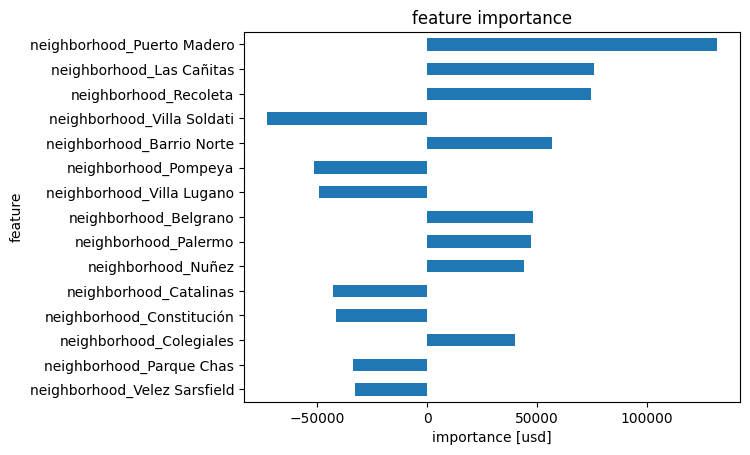

In [18]:
feat_imp.sort_values(key=abs).tail(15).plot(kind="barh")
plt.xlabel("importance [usd]")
plt.ylabel("feature")
plt.title("feature importance")